## 0 - Introduction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

In [2]:
# To properly visualization
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# To reset the options to their default values uncomment the following lines and run the cell
# pd.reset_option("display.max_rows")
# pd.reset_option("display.max_columns")
# pd.reset_option("display.max_colwidth")
# pd.reset_option("display.width")

In [3]:
url_bgdata = "../data/Background/Background/"
url_ds = "/csv/features_dataset.csv"

In [4]:
DIM_CUBE = 10

cols = [
    'event_index', 
    'pixel_ijk', 
    'primary_e0_kev',
    #'n_voxels', 
    # 'E_sum', 
    # 'E_mean', 
    # 'E_std', 
    # 'E_min', 
    # 'E_max', 
    # 'E_median', 
    # 'E_p10', 
    # 'E_p25', 
    # 'E_p75', 
    # 'E_p90', 
    # 'E_p95', 
    # 'E_p99', 
    # 'E_iqr', 
    # 'E_mad', 
    # 'E_skew', 
    # 'E_kurt', 
    # 'entropy', 
    # 'gini', 
    'n_active', 
    # 'frac_active', 
    # 'frac_top1', 
    # 'frac_top3', 
    # 'eff_E_ge_T', 
    # 'com_x', 
    # 'com_y', 
    # 'com_z', 
    # 'rg', 
    # 'lam1', 
    # 'lam2', 
    # 'lam3', 
    # 'linearity', 
    # 'planarity', 
    # 'sphericity', 
    # 'asym_x', 
    # 'asym_y', 
    # 'asym_z', 
    # 'span_x', 
    # 'span_y', 
    # 'span_z', 
    'hits_sum', 
    'hits_mean_active', 
    # 'corr_E_hits', 
    # 'D_f', 
    # 'D_f_r2', 
    # 'f_occ', 
    # 'L_max_hops', 
    # 'L_max_metric', 
    # 'N_b', 
    # 'L_skel'
]

Define some useful functions:

In [5]:
def pixel_conversion(pixel_ijk):
    """
    Convert pixel_ijk string to a list of tuples (i, j, k).
    Pixels are in format "[i, j , k];[i, j, k];...;[i, j, k]"
    """
    pixels_no_brackets = pixel_ijk.replace("[", "").replace("]", "")
    pixel_coord = pixels_no_brackets.split(",")

    i, j, k = map(int, pixel_coord)
    return i, j, k
    
# ### Test
# print("Test pixel conversion:")
# p1 = "[1, 2, 3]"
# i, j, k = pixel_conversion(p1)
# print(f"Input: {p1} -> Output: i={i}, j={j}, k={k}")

In [6]:
def create_detection_cube(hits_matrix, gap=0.02, colorscale="Plasma", opacity=0.9, min_hitted=0, show_arrows=True):
    """
    Create a 3D visualization of the detector activation with proportional 3D Cartesian arrow axes.

    Parameters:
        hits_matrix: A 3D numpy array representing the total hits in each sub-cube of the detector.
        gap: Spacing between sub-cubes.
        colorscale: Plotly colorscale for the voxels.
        opacity: Opacity of the voxel meshes.
        min_hitted: Minimum threshold for hits to be displayed.
        show_arrows: If True, draws 3D arrow axes (I, J, K) starting from the origin.
    """
    values = np.asarray(hits_matrix)
    nx, ny, nz = values.shape
    size = 1.0 - gap

    # Vertex and face definitions for a unit cube
    base_v = np.array([
        [0, 0, 0], [size, 0, 0], [size, size, 0], [0, size, 0],
        [0, 0, size], [size, 0, size], [size, size, size], [0, size, size]
    ])
    base_triangles = np.array([
        [7, 3, 0], [0, 4, 7], [0, 1, 2], [0, 2, 3],
        [4, 5, 6], [4, 6, 7], [6, 5, 1], [6, 1, 2],
        [4, 0, 1], [4, 1, 5], [3, 2, 6], [3, 6, 7]
    ])
    edge_seq = [0, 1, 2, 3, 0, 4, 5, 6, 7, 4, None, 1, 5, None, 2, 6, None, 3, 7]

    all_vx, all_vy, all_vz = [], [], []
    all_i, all_j, all_k = [], [], []
    intensity_list = []
    edge_x, edge_y, edge_z = [], [], []

    # Takes only coordinates with hits strictly greater than min_hitted
    active_coords = np.argwhere(values > min_hitted)

    if len(active_coords) == 0:
        print("Attenzione: nessun voxel con hit >", min_hitted)
        return go.Figure()

    vert_offset = 0
    for x, y, z in active_coords:
        val = values[x, y, z]
        cube_v = base_v + np.array([x, y, z])

        all_vx.extend(cube_v[:, 0])
        all_vy.extend(cube_v[:, 1])
        all_vz.extend(cube_v[:, 2])

        intensity_list.extend([val] * 8)

        shifted_tri = base_triangles + vert_offset
        all_i.extend(shifted_tri[:, 0])
        all_j.extend(shifted_tri[:, 1])
        all_k.extend(shifted_tri[:, 2])
        vert_offset += 8

        # Black edges for each cube
        for idx in edge_seq:
            if idx is None:
                edge_x.append(None); edge_y.append(None); edge_z.append(None)
            else:
                edge_x.append(cube_v[idx, 0])
                edge_y.append(cube_v[idx, 1])
                edge_z.append(cube_v[idx, 2])
        edge_x.append(None); edge_y.append(None); edge_z.append(None)

    # 1. Mesh of active voxels
    mesh = go.Mesh3d(
        x=all_vx, y=all_vy, z=all_vz,
        i=all_i, j=all_j, k=all_k,
        intensity=intensity_list,
        intensitymode='vertex',
        colorscale=colorscale,
        cmin=float(np.min(values[values > min_hitted])),
        cmax=float(np.max(values)),
        opacity=opacity,
        flatshading=True,
        colorbar=dict(title="Hits"),
        name="Hits"
    )

    # 2. Voxel outlines
    edges = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(color='black', width=1.5),
        hoverinfo='none',
        showlegend=False
    )

    # 3. Detector bounding box
    bbox_x = [0, nx, nx, 0, 0, 0, nx, nx, 0, 0, None, nx, nx, None, nx, nx, None, 0, 0]
    bbox_y = [0, 0, ny, ny, 0, 0, 0, ny, ny, 0, None, 0, 0, None, ny, ny, None, ny, ny]
    bbox_z = [0, 0, 0, 0, 0, nz, nz, nz, nz, nz, None, 0, nz, None, 0, nz, None, 0, nz]
    
    bounding_box = go.Scatter3d(
        x=bbox_x, y=bbox_y, z=bbox_z,
        mode='lines',
        line=dict(color='gray', width=2, dash='dot'),
        hoverinfo='none',
        showlegend=False
    )

    data = [mesh, edges, bounding_box]

    # 4. Proportional Cartesian Arrow Axes
    if show_arrows:
        max_d = max(nx, ny, nz)
        axis_len = max_d * 1.15
        head_len = max_d * 0.12

        axes_cfg = [
            ('I', 'red',   [0, axis_len, 0, 0, 0, 0], [head_len, 0, 0], [axis_len * 1.12, 0, 0]),
            ('J', 'green', [0, 0, 0, axis_len, 0, 0], [0, head_len, 0], [0, axis_len * 1.12, 0]),
            ('K', 'blue',  [0, 0, 0, 0, 0, axis_len], [0, 0, head_len], [0, 0, axis_len * 1.12])
        ]

        for name, color, coords, vec, label_p in axes_cfg:
            # Shaft line
            data.append(go.Scatter3d(
                x=[coords[0], coords[1]],
                y=[coords[2], coords[3]],
                z=[coords[4], coords[5]],
                mode='lines',
                line=dict(color=color, width=5),
                hoverinfo='none',
                showlegend=False
            ))

            # Arrowhead cone
            data.append(go.Cone(
                x=[coords[1]], y=[coords[3]], z=[coords[5]],
                u=[vec[0]], v=[vec[1]], w=[vec[2]],
                anchor='tail',
                sizemode='scaled',
                sizeref=1.0,
                colorscale=[[0, color], [1, color]],
                showscale=False,
                hoverinfo='none'
            ))

            # Axis label
            data.append(go.Scatter3d(
                x=[label_p[0]], y=[label_p[1]], z=[label_p[2]],
                mode='text',
                text=[f'<b>{name}</b>'],
                textfont=dict(color=color, size=15),
                hoverinfo='none',
                showlegend=False
            ))

    fig = go.Figure(data=data)
    
    max_range = max(nx, ny, nz) * 1.25
    max_range = max(nx, ny, nz) * 1.25
    fig.update_layout(
        scene=dict(
            aspectmode='data',
            xaxis=dict(
                title='I (pixel)', 
                range=[-0.5, max_range],
                showbackground=False,  
                showgrid=False,        
                showline=False,       
                zeroline=False
            ),
            yaxis=dict(
                title='J (pixel)', 
                range=[-0.5, max_range],
                showbackground=False,
                showgrid=False,
                showline=False,
                zeroline=False
            ),
            zaxis=dict(
                title='K (pixel)', 
                range=[-0.5, max_range],
                showbackground=False,
                showgrid=False,
                showline=False,
                zeroline=False
            )
        ),
        paper_bgcolor='white',  
        margin=dict(l=0, r=0, b=0, t=30)
    )
    return fig

In [7]:
def plot_detector_layes(hits_matrix, colorscale="plasma", min_hitted=0):
    """
        Create a 2D visualization of the dector activation by plotting each layer of the 3D hits matrix as a separate subplot as heatmap.
        The view is along x-axis, so each subplot represents a slice of the detector along the x-axis.
    """
    n_layers = hits_matrix.shape[0]
    ncols = 2
    nrows = int(np.ceil(n_layers / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i in range(n_layers):
        # .T make the X axis correspond to J and the Y axis to K
        sns.heatmap(
            hits_matrix[i, :, :].T, 
            ax=axes[i], 
            cmap=colorscale, 
            cbar=True, 
            square=True, 
            annot=True, 
            fmt=".0f", 
            linewidths=0.5, 
            linecolor='black', 
            vmin=min_hitted
        )

        axes[i].invert_yaxis()

        axes[i].set_title(f'I = {i} (layer {i+1}/{n_layers})')
        axes[i].set_xlabel('J (pixel)')
        axes[i].set_ylabel('K (pixel)')

    # Turn off any unused subplots
    for j in range(n_layers, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# # Test
# sample_hits_matrix = np.random.randint(0, 100, size=(4, 4, 4))
# plot_detector_layes(sample_hits_matrix, min_hitted=0)

## 1 - Albedo Photons

In [8]:
url_albedophotons = url_bgdata + "AlbedoPhotons_20260917_160430" + url_ds

albedo = pd.read_csv(url_albedophotons, header=0)
print("Albedo Photons dataset shape:", albedo.shape)

albedo = albedo[cols]
print("Albedo Photons dataset shape after selecting columns:", albedo.shape)
print("Selected columns:", albedo.columns.tolist())

Albedo Photons dataset shape: (86862, 53)
Albedo Photons dataset shape after selecting columns: (86862, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [9]:
if "hits_sum" in albedo.columns and "n_active" in albedo.columns:
    discrepancies = albedo[albedo["n_active"] != albedo["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        albedo = albedo.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in albedo.columns and "n_active" in albedo.columns:
    for i in range(albedo.shape[0]):
        pixel_ijk = albedo.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = albedo.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [10]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in albedo["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

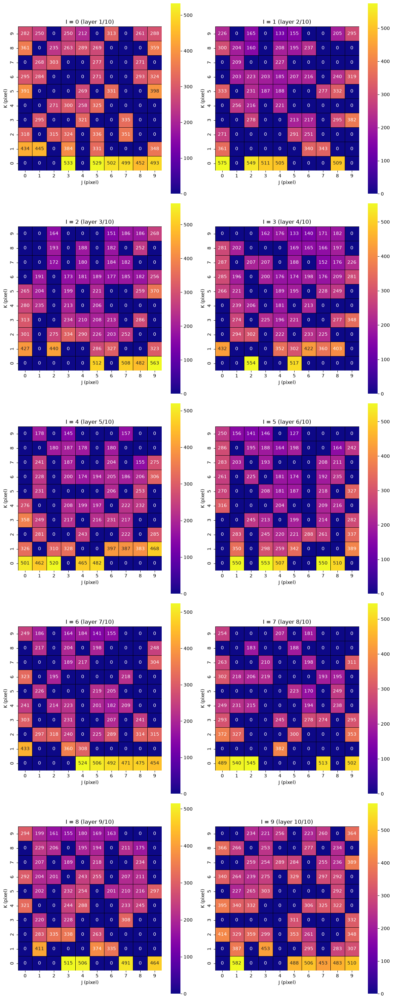

In [11]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 2 - Atmospheric Neutrons

In [12]:
url_atmosphericneutrons = url_bgdata + "AtmosphericNeutrons_20260917_161622" + url_ds

atm_neutrons = pd.read_csv(url_atmosphericneutrons, header=0)
print("Atmospheric Neutrons dataset shape:", atm_neutrons.shape)

atm_neutrons = atm_neutrons[cols]
print("Atmospheric Neutrons dataset shape after selecting columns:", atm_neutrons.shape)
print("Selected columns:", atm_neutrons.columns.tolist())

Atmospheric Neutrons dataset shape: (2161, 53)
Atmospheric Neutrons dataset shape after selecting columns: (2161, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [13]:
if "hits_sum" in atm_neutrons.columns and "n_active" in atm_neutrons.columns:
    discrepancies = atm_neutrons[atm_neutrons["n_active"] != atm_neutrons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        atm_neutrons = atm_neutrons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in atm_neutrons.columns and "n_active" in atm_neutrons.columns:
    for i in range(atm_neutrons.shape[0]):
        pixel_ijk = atm_neutrons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = atm_neutrons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [14]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in atm_neutrons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

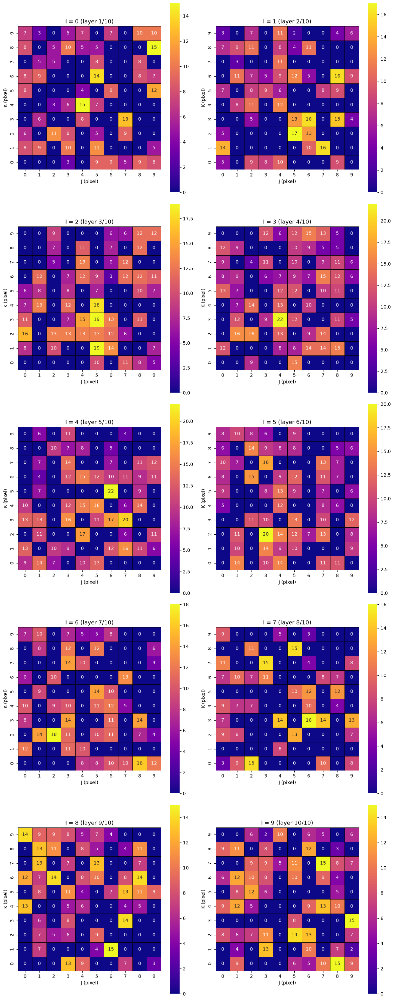

In [15]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 3 - Cosmic Photons

In [53]:
url_cosmicphotons = url_bgdata + "CosmicPhotons_20260917_161711" + url_ds

cosmic_pht = pd.read_csv(url_cosmicphotons, header=0)
print("Cosmic Photons dataset shape:", cosmic_pht.shape)

cosmic_pht = cosmic_pht[cols]
print("Cosmic Photons dataset shape after selecting columns:", cosmic_pht.shape)
print("Selected columns:", cosmic_pht.columns.tolist())

Cosmic Photons dataset shape: (152860, 53)
Cosmic Photons dataset shape after selecting columns: (152860, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [17]:
if "hits_sum" in cosmic_pht.columns and "n_active" in cosmic_pht.columns:
    discrepancies = cosmic_pht[cosmic_pht["n_active"] != cosmic_pht["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        cosmic_pht = cosmic_pht.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in cosmic_pht.columns and "n_active" in cosmic_pht.columns:
    for i in range(cosmic_pht.shape[0]):
        pixel_ijk = cosmic_pht.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = cosmic_pht.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [18]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in cosmic_pht["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

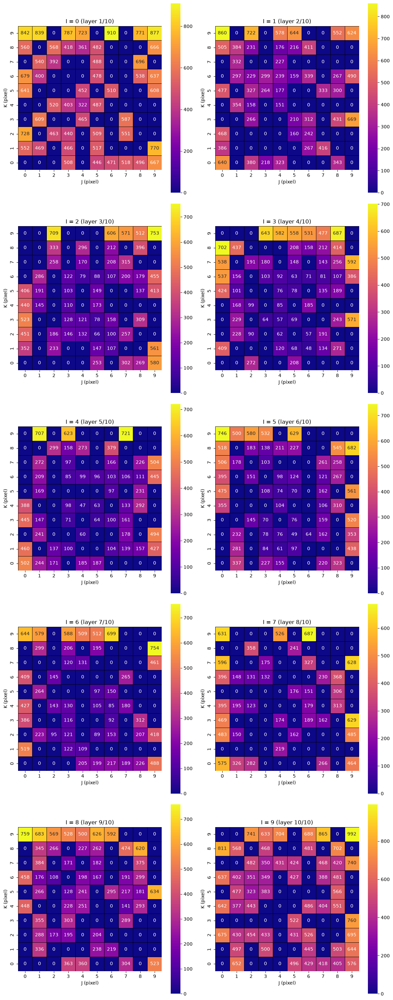

In [19]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 4 - Primary Alphas

In [20]:
url_primaryalpha = url_bgdata + "PrimaryAlphas_20260917_163423" + url_ds

prim_alphas = pd.read_csv(url_primaryalpha, header=0)
print("Primary Alphas dataset shape:", prim_alphas.shape)

prim_alphas = prim_alphas[cols]
print("Primary Alphas dataset shape after selecting columns:", prim_alphas.shape)
print("Selected columns:", prim_alphas.columns.tolist())

Primary Alphas dataset shape: (2781, 53)
Primary Alphas dataset shape after selecting columns: (2781, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [21]:
if "hits_sum" in prim_alphas.columns and "n_active" in prim_alphas.columns:
    discrepancies = prim_alphas[prim_alphas["n_active"] != prim_alphas["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        prim_alphas = prim_alphas.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in prim_alphas.columns and "n_active" in prim_alphas.columns:
    for i in range(prim_alphas.shape[0]):
        pixel_ijk = prim_alphas.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = prim_alphas.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [22]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in prim_alphas["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

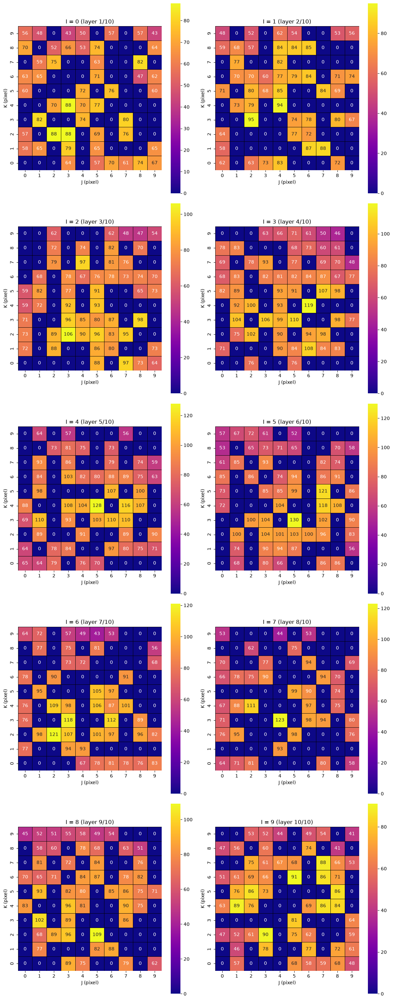

In [23]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 5 - Primary Electrons

In [24]:
url_primaryelectrons = url_bgdata + "PrimaryElectrons_20260917_163621" + url_ds

prim_electrons = pd.read_csv(url_primaryelectrons, header=0)
print("Primary Electrons dataset shape:", prim_electrons.shape)

prim_electrons = prim_electrons[cols]
print("Primary Electrons dataset shape after selecting columns:", prim_electrons.shape)
print("Selected columns:", prim_electrons.columns.tolist())

Primary Electrons dataset shape: (148, 53)
Primary Electrons dataset shape after selecting columns: (148, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [25]:
if "hits_sum" in prim_electrons.columns and "n_active" in prim_electrons.columns:
    discrepancies = prim_electrons[prim_electrons["n_active"] != prim_electrons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        prim_electrons = prim_electrons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in prim_electrons.columns and "n_active" in prim_electrons.columns:
    for i in range(prim_electrons.shape[0]):
        pixel_ijk = prim_electrons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = prim_electrons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [26]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in prim_electrons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

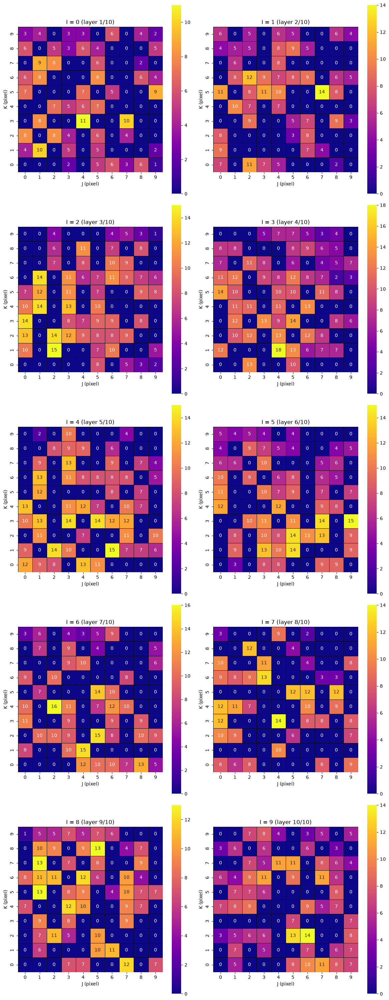

In [27]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 6 - Primary Positrons

In [28]:
url_primarypositron = url_bgdata + "PrimaryPositrons_20260917_163647" + url_ds

prim_positrons = pd.read_csv(url_primarypositron, header=0)
print("Primary Positrons dataset shape:", prim_positrons.shape)

prim_positrons = prim_positrons[cols]
print("Primary Positrons dataset shape after selecting columns:", prim_positrons.shape)
print("Selected columns:", prim_positrons.columns.tolist())

Primary Positrons dataset shape: (4, 53)
Primary Positrons dataset shape after selecting columns: (4, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [29]:
if "hits_sum" in prim_positrons.columns and "n_active" in prim_positrons.columns:
    discrepancies = prim_positrons[prim_positrons["n_active"] != prim_positrons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        prim_positrons = prim_positrons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in prim_positrons.columns and "n_active" in prim_positrons.columns:
    for i in range(prim_positrons.shape[0]):
        pixel_ijk = prim_positrons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = prim_positrons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [30]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in prim_positrons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

In [31]:
tot_hitted = np.sum(hits_matrix)
print(f"Total number of hitted voxels: {tot_hitted}")

prim_positrons.head()

Total number of hitted voxels: 89.0


,event_index,pixel_ijk,primary_e0_kev,n_active,hits_mean_active
0,1,"[5,5,3];[5,4,2];[6,3,2];[5,3,2];[7,0,0];[6,3,1];[6,0,1];[6,2,2];[4,7,4];[5,3,1];[7,2,0];[6,4,1];[5,5,2];[7,2,6];[7,0,2];[4,5,3];[4,6,3];[4,8,4];[6,1,2];[5,3,0];[7,1,0];[7,1,2];[9,2,6];[6,3,3];[3,2,2];[4,4,2];[5,1,1];[5,6,2];[5,7,4];[5,1,2];[4,1,2];[6,0,3];[5,4,0];[6,5,2];[8,3,5];[7,4,1];[5,4,1];[6,3,4];[9,1,0];[7,0,6];[6,0,4];[4,8,5];[4,0,3];[5,1,0];[7,6,4];[4,3,3];[6,2,4];[2,2,8];[9,6,1];[8,4,0];[9,3,6];[6,4,0];[7,6,5];[7,0,4];[6,2,6];[8,1,1];[2,2,1];[6,6,3];[7,0,7];[4,3,1];[9,6,0];[5,5,6];[2,6,6];[3,8,5];[6,5,4];[3,4,3];[8,2,6];[8,2,2];[2,3,3];[8,5,2];[4,4,6];[5,5,1];[7,4,3];[9,1,1];[8,3,2];[8,3,4];[8,6,1];[4,3,4];[9,2,5];[7,7,0];[2,5,4];[6,1,5];[4,2,0];[8,1,3]",6.044554e+06,84,1.0
1,3,"[9,3,9];[9,3,8]",1.184597e+07,2,1.0
2,4,"[7,7,0];[7,9,0]",2.096510e+07,2,1.0
3,6,"[0,6,9]",8.727812e+06,1,1.0


Plot the detector hitted-subcubes in 2D layer by layer:

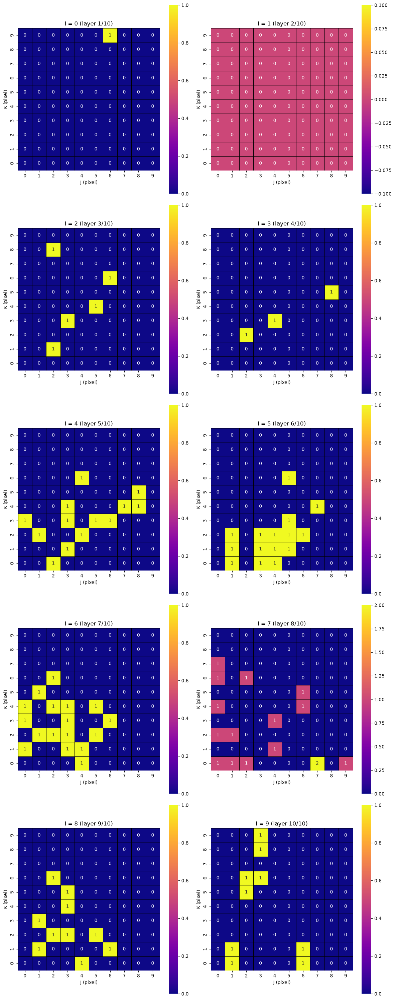

In [32]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

## 7 - Primary Protons

In [33]:
url_primaryprotons = url_bgdata + "PrimaryProtons_20260917_163703" + url_ds

prim_protons = pd.read_csv(url_primaryprotons, header=0)
print("Primary Protons dataset shape:", prim_protons.shape)

prim_protons = prim_protons[cols]
print("Primary Protons dataset shape after selecting columns:", prim_protons.shape)
print("Selected columns:", prim_protons.columns.tolist())

Primary Protons dataset shape: (18461, 53)
Primary Protons dataset shape after selecting columns: (18461, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [34]:
if "hits_sum" in prim_protons.columns and "n_active" in prim_protons.columns:
    discrepancies = prim_protons[prim_protons["n_active"] != prim_protons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        prim_protons = prim_protons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in prim_protons.columns and "n_active" in prim_protons.columns:
    for i in range(prim_protons.shape[0]):
        pixel_ijk = prim_protons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = prim_protons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [35]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in prim_protons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

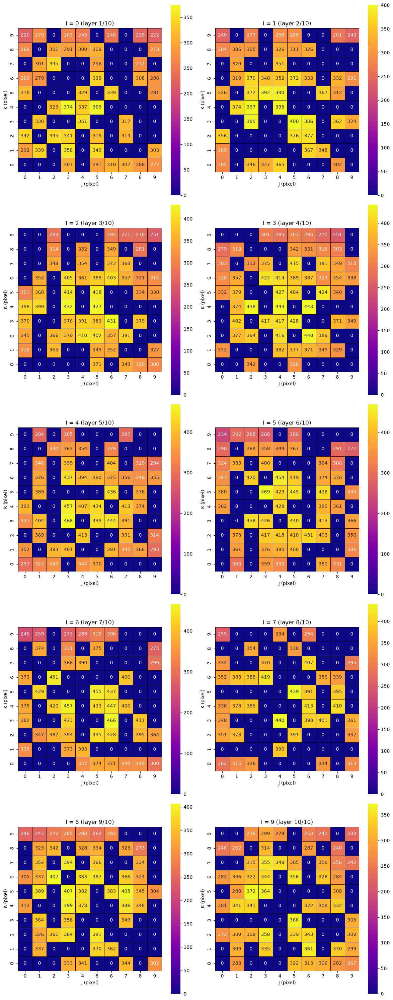

In [36]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

# 8 - Secondary Electrons

In [37]:
url_secondaryelectrons = url_bgdata + "SecondaryElectrons_20260917_164325" + url_ds

sec_electrons = pd.read_csv(url_secondaryelectrons, header=0)
print("Secondary Electrons dataset shape:", sec_electrons.shape)

sec_electrons = sec_electrons[cols]
print("Secondary Electrons dataset shape after selecting columns:", sec_electrons.shape)
print("Selected columns:", sec_electrons.columns.tolist())

Secondary Electrons dataset shape: (8730, 53)
Secondary Electrons dataset shape after selecting columns: (8730, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [38]:
if "hits_sum" in sec_electrons.columns and "n_active" in sec_electrons.columns:
    discrepancies = sec_electrons[sec_electrons["n_active"] != sec_electrons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        sec_electrons = sec_electrons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in sec_electrons.columns and "n_active" in sec_electrons.columns:
    for i in range(sec_electrons.shape[0]):
        pixel_ijk = sec_electrons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = sec_electrons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [39]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in sec_electrons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

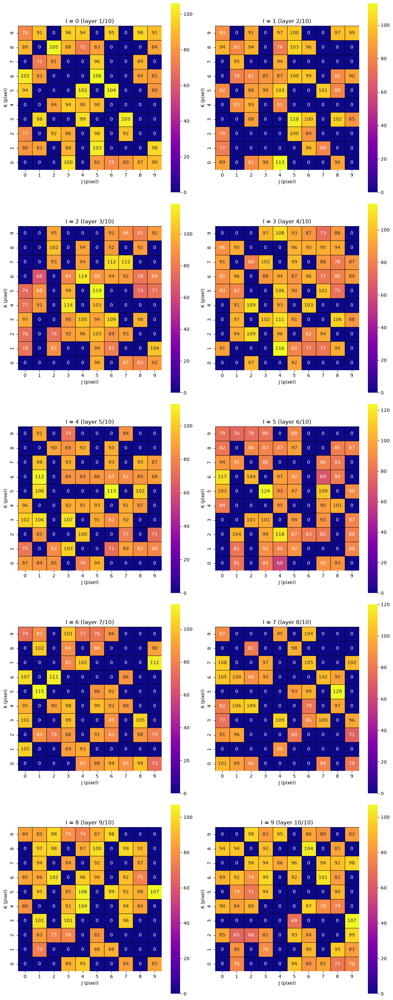

In [40]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

# 9 - Secondary Positrons 

In [41]:
url_secondarypositrons = url_bgdata + "SecondaryPositrons_20260917_164524" + url_ds

sec_positrons = pd.read_csv(url_secondarypositrons, header=0)
print("Secondary Positrons dataset shape:", sec_positrons.shape)

sec_positrons = sec_positrons[cols]
print("Secondary Positrons dataset shape after selecting columns:", sec_positrons.shape)
print("Selected columns:", sec_positrons.columns.tolist())

Secondary Positrons dataset shape: (29089, 53)
Secondary Positrons dataset shape after selecting columns: (29089, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [42]:
if "hits_sum" in sec_positrons.columns and "n_active" in sec_positrons.columns:
    discrepancies = sec_positrons[sec_positrons["n_active"] != sec_positrons["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        sec_positrons = sec_positrons.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in sec_positrons.columns and "n_active" in sec_positrons.columns:
    for i in range(sec_positrons.shape[0]):
        pixel_ijk = sec_positrons.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = sec_positrons.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [43]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in sec_positrons["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

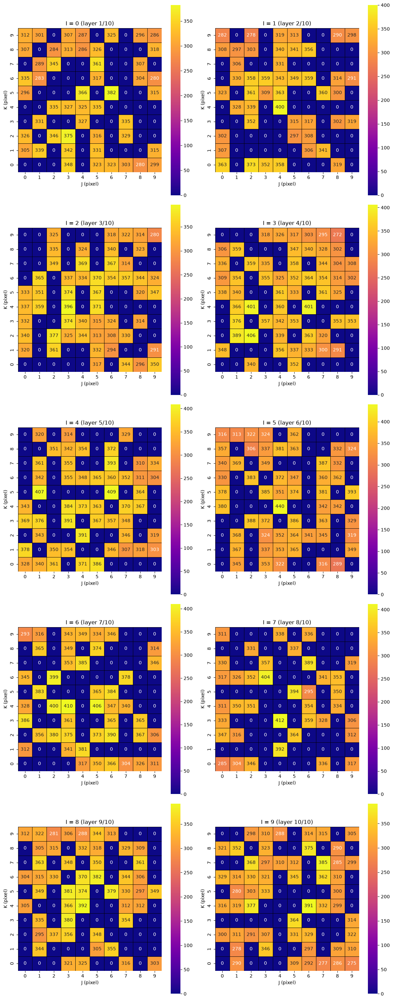

In [44]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

# 10 - Secondary Protons (Downward)

In [45]:
url_secondaryprotons_downward = url_bgdata + "SecondaryProtonsDownward_20260917_165127" + url_ds

sec_protons_dw = pd.read_csv(url_secondaryprotons_downward, header=0)
print("Secondary Protons (Downward) dataset shape:", sec_protons_dw.shape)

sec_protons_dw = sec_protons_dw[cols]
print("Secondary Protons (Downward) dataset shape after selecting columns:", sec_protons_dw.shape)
print("Selected columns:", sec_protons_dw.columns.tolist())

Secondary Protons (Downward) dataset shape: (11060, 53)
Secondary Protons (Downward) dataset shape after selecting columns: (11060, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [46]:
if "hits_sum" in sec_protons_dw.columns and "n_active" in sec_protons_dw.columns:
    discrepancies = sec_protons_dw[sec_protons_dw["n_active"] != sec_protons_dw["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        sec_protons_dw = sec_protons_dw.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in sec_protons_dw.columns and "n_active" in sec_protons_dw.columns:
    for i in range(sec_protons_dw.shape[0]):
        pixel_ijk = sec_protons_dw.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = sec_protons_dw.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [47]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in sec_protons_dw["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

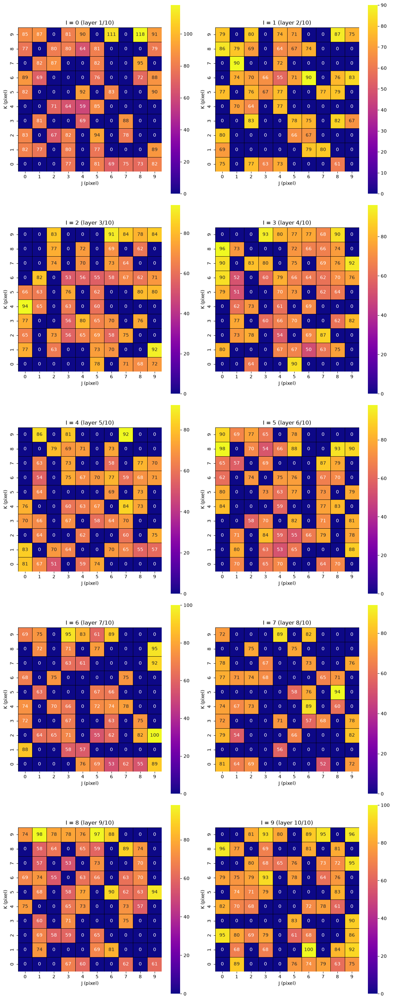

In [48]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

# 11 - Secondary Protons (Upward)

In [49]:
url_secondaryprotons_upwards = url_bgdata + "SecondaryProtonsUpward_20260917_165336" + url_ds

sec_protons_up = pd.read_csv(url_secondaryprotons_upwards, header=0)
print("Secondary Protons Upward dataset shape:", sec_protons_up.shape)

sec_protons_up = sec_protons_up[cols]
print("Secondary Protons Upward dataset shape after selecting columns:", sec_protons_up.shape)
print("Selected columns:", sec_protons_up.columns.tolist())

Secondary Protons Upward dataset shape: (11901, 53)
Secondary Protons Upward dataset shape after selecting columns: (11901, 6)
Selected columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_active', 'hits_sum', 'hits_mean_active']


Check if the `n_active` and `hits_sum` are the same value and if it is consistend with the dimension of `pixel_ijk`: 

In [50]:
if "hits_sum" in sec_protons_up.columns and "n_active" in sec_protons_up.columns:
    discrepancies = sec_protons_up[sec_protons_up["n_active"] != sec_protons_up["hits_sum"]]
    print("Discrepnacies between n_active and hits_sum:", discrepancies.shape[0])

    if discrepancies.shape[0] == 0:
        print("Drop hits_sum column since it is redundant with n_active")
        sec_protons_up = sec_protons_up.drop(columns=["hits_sum"])

# check consisntency between n_active and dimension of pixel_ijk
if "pixel_ijk" in sec_protons_up.columns and "n_active" in sec_protons_up.columns:
    for i in range(sec_protons_up.shape[0]):
        pixel_ijk = sec_protons_up.iloc[i]["pixel_ijk"]
        number_of_pixels = len(pixel_ijk.split(";")) if isinstance(pixel_ijk, str) else 0
        n_active = sec_protons_up.iloc[i]["n_active"]
        if number_of_pixels != n_active:
            print(f"Discrepancy at index {i}: n_active = {n_active}, number of pixels in pixel_ijk = {number_of_pixels}")

print("No discrepancies!")

Discrepnacies between n_active and hits_sum: 0
Drop hits_sum column since it is redundant with n_active
No discrepancies!


Do a 3D plot of the hitted sub-cubes:

In [51]:
hits_matrix = np.zeros((DIM_CUBE, DIM_CUBE, DIM_CUBE))

for pixels_ijk in sec_protons_up["pixel_ijk"]:
    for pixel_str in pixels_ijk.split(";"):
        i, j, k = pixel_conversion(pixel_str)
        hits_matrix[i, j, k] += 1

# Normalization of the hits matrix to have values between 0 and 1
# max_val = np.max(hits_matrix)
# if max_val > 0:
#     hits_matrix /= max_val

fig = create_detection_cube(
    hits_matrix,
    gap=0.08,
    colorscale="Plasma",   # Turbo or Plasma
    opacity=0.9,
    min_hitted=0.0      
)
fig.show()

Plot the detector hitted-subcubes in 2D layer by layer:

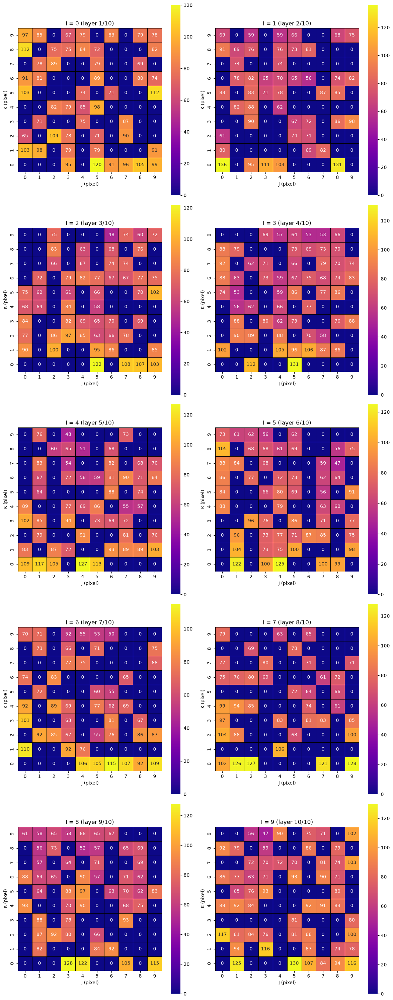

In [52]:
plot_detector_layes(
    hits_matrix,
    colorscale="plasma", 
    min_hitted=0.0
)

# Comparison

In this section the hit informations are compared.

In [57]:
background_sources = {
    "Albedo Photons": albedo,
    "Atmospheric Neutrons": atm_neutrons,
    "Cosmic Photons": cosmic_pht,
    "Primary Alphas": prim_alphas,
    "Primary Electrons": prim_electrons,
    "Primary Positrons": prim_positrons,
    "Primary Protons": prim_protons,
    "Secondary Electrons": sec_electrons,
    "Secondary Positrons": sec_positrons,
    "Secondary Protons Downward": sec_protons_dw,
    "Secondary Protons Upward": sec_protons_up
}


In [74]:
rows = []

for source, df in background_sources.items():
    hits = pd.to_numeric(df["n_active"], errors="coerce").dropna()

    k_values = []
    j_values = []
    i_values = []
    for pixel_ijk in df["pixel_ijk"].dropna():
        for pixel_str in pixel_ijk.split(";"):
            i, j, k = pixel_conversion(pixel_str)
            i_values.append(i)
            j_values.append(j)
            k_values.append(k)

    rows.append({
        "Source": source,
        "Num. Events": len(hits),
        "Total Hits": hits.sum(),
        "Mean Hits": hits.mean(),
        "Std. Hits": hits.std(),
        "Median Hits": hits.median(),
        "Min Hits": hits.min(),
        "Max Hits": hits.max(),
        "Barycenter I": np.mean(i_values).round(2),
        "Barycenter J": np.mean(j_values).round(2),
        "Barycenter K": np.mean(k_values).round(2),
    })

hits_stats_df = pd.DataFrame(rows).set_index("Source")

hits_stats_df

,Num. Events,Total Hits,Mean Hits,Std. Hits,Median Hits,Min Hits,Max Hits,Barycenter I,Barycenter J,Barycenter K
Source,,,,,,,,,,
Albedo Photons,86862,138423,1.593597,2.010771,1.0,1,86,4.49,4.42,3.89
Atmospheric Neutrons,2161,4755,2.200370,2.863584,1.0,1,37,4.44,4.41,4.39
Cosmic Photons,152860,170910,1.118082,0.410773,1.0,1,31,4.49,4.43,5.16
Primary Alphas,2781,38633,13.891766,30.557520,5.0,1,327,4.48,4.42,4.40
Primary Electrons,148,4014,27.121622,35.759002,12.5,1,203,4.57,4.16,4.28
Primary Positrons,4,89,22.250000,41.169366,2.0,1,84,5.85,3.36,2.89
Primary Protons,18461,173830,9.416066,18.916254,5.0,1,280,4.48,4.38,4.49
Secondary Electrons,8730,45335,5.193013,7.485731,2.0,1,155,4.45,4.39,4.66
Secondary Positrons,29089,168679,5.798721,7.363655,3.0,1,132,4.48,4.36,4.61
